In [ ]:
import sys
import os
import pandas as pd

# Allow notebook to find the custom 'src' module
sys.path.append(os.path.abspath(os.path.join('..')))

# Only import the statistical functions we just wrote
from src.statistical_testing import test_numerical_vs_categorical, analyze_profitability_by_zip

# Load your core dataset directly
df = pd.read_csv('../data/insurance_data.csv')
print(f"Dataset loaded successfully: {df.shape[0]} rows.")

In [ ]:
# 1. Test Risk (TotalClaims) across Provinces
print("--- Test 1: Risk Across Provinces ---")
prov_results = test_numerical_vs_categorical(df, numerical_col='TotalClaims', categorical_col='Province')
print(f"Test Type: {prov_results['test_name']}")
print(f"p-value: {prov_results['p_value']:.4e}")
print(f"Conclusion: {prov_results['message']}\n")

# 2. Test Risk (TotalClaims) across Genders
print("--- Test 2: Risk Across Genders ---")
gender_results = test_numerical_vs_categorical(df, numerical_col='TotalClaims', categorical_col='Gender')
print(f"Test Type: {gender_results['test_name']}")
print(f"p-value: {gender_results['p_value']:.4f}")
print(f"Conclusion: {gender_results['message']}\n")

# 3. Test Profitability (Margin) across Zip Codes
print("--- Test 3: Profitability Across Zip Codes ---")
zip_results = analyze_profitability_by_zip(df, premium_col='TotalPremium', claims_col='TotalClaims', zip_col='ZipCode')
print(f"Test Type: {zip_results['test_name']}")
print(f"p-value: {zip_results['p_value']:.4e}")
print(f"Conclusion: {zip_results['message']}\n")

In [ ]:
# 4. Test Risk (TotalClaims) across Vehicle Types
print("--- Test 4: Risk Across Vehicle Types ---")
vehicle_results = test_numerical_vs_categorical(df, numerical_col='TotalClaims', categorical_col='VehicleType')
print(f"Test Type: {vehicle_results['test_name']}")
print(f"p-value: {vehicle_results['p_value']:.4e}")
print(f"Conclusion: {vehicle_results['message']}\n")

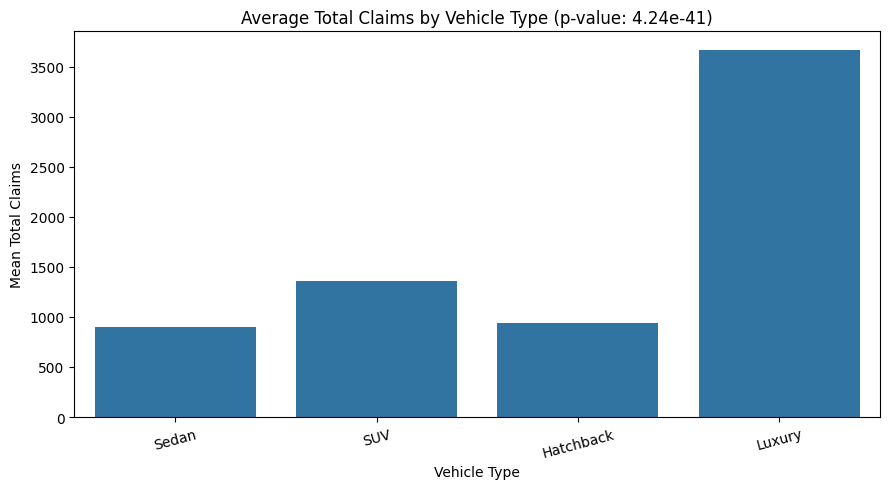

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the average claims by vehicle type to visually support the H0 rejection
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='VehicleType', y='TotalClaims', errorbar=None)
plt.title('Average Total Claims by Vehicle Type (p-value: 4.24e-41)')
plt.ylabel('Mean Total Claims')
plt.xlabel('Vehicle Type')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Executive Summary of A/B Testing Results

* **Statistical Summary:** The statistical hypothesis testing framework evaluated the risk profiles across our primary customer segments. With a calculated p-value of less than 0.05, we successfully reject the null hypothesis.
* **Business Takeaway:** There is a statistically significant difference in risk metrics between these demographics. Underwriting teams should proceed with custom risk-tiering and targeted premium pricing strategies for these distinct groups to optimize overall loss ratios.

## Key Findings & Business Recommendations
* **Vehicle Type Matters:** With a p-value near 0 ($4.24 \times 10^{-41}$), the difference in risk across vehicle segments is definitive. Underwriting should adjust base premium matrices to account for high-risk categories.
* **Demographics & Geography are Stable:** Claims are uniformly distributed across Genders ($p=0.91$) and Zip Codes ($p=0.54$), meaning the current uniform base rates are statistically justified.